# Reverse-Repo-Drain — a quantitative teardown 🔬
### A hardcoded ON RRP proxy (FRED `RRPONTSYD`) vs month-end SPY · drain-vs-fill regime means · a Welch *t* + a block-bootstrap null on few long regimes · a drain-timing-vs-buy-and-hold Sharpe race · a synthetic faithful-engine / power control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Liquidity_tell%3F: Busted](https://img.shields.io/badge/Liquidity_tell%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The claim "a draining ON RRP marks risk-on" is a **regime** hypothesis on a **single** fill-then-drain episode, so the entire teardown is one question asked carefully: is the drain-minus-fill forward-return spread distinguishable from what one big drain lining up with one big rally produces by chance? We confront it with a Welch *t*, a block-bootstrap null that respects the long regimes, and a costs-net Sharpe race.

> ⚠️ **Data + proxy note.** The ON RRP balance isn't on yfinance; we ship a **small, clearly-labelled hardcoded monthly proxy** of the public FRED series `RRPONTSYD` (rounded end-of-month levels, quarter-end spikes smoothed) — the 2021 fill, the ~$2.55T Dec-2022 peak, the 2023-25 drain. SPY is yfinance **total-return** (auto-adjust), month-end. The verdict turns on the *shape of one episode*, not the marks. Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from reverse_repo_drain import data, strategy as st

HAVE_REAL = data.have_real()
F = data.build_real() if HAVE_REAL else None
print("real SPY cache present:", HAVE_REAL,
      "| monthly observations:", (0 if F is None else len(F)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2021-01-31', 'end': '2025-07-31', 'months': 55, 'years': 4.5, 'rrp_peak': 2554, 'rrp_peak_date': '2022-12', 'rrp_last': 195, 'base_mean': 1.22, 'base_win': 65, 'corr': -0.014, 'k1': (1, 28, 25, 0.71, 1.73, -1.02, -0.8, 0.819, 54, 76), 'k2': (2, 26, 26, 1.23, 1.01, 0.22, 0.17, 0.445, 62, 65), 'k3': (3, 27, 24, 0.94, 1.16, -0.22, -0.17, 0.566, 56, 71), 'k6': (6, 28, 20, 1.58, 0.18, 1.4, 0.92, 0.065, 68, 50), 'k9': (9, 27, 18, 1.7, -0.19, 1.89, 1.2, 0.104, 67, 50), 'k12': (12, 25, 17, 1.6, 0.23, 1.38, 0.83, 0.101, 64, 59), 'timing': [('long / flat', 53, 14, 0.52, 0.49, 5.6, 0.78), ('long / short', 53, 29, -0.04, -0.08, -1.3, 0.78)], 'wealth_lf': 1.24, 'wealth_bh': 1.61, 'syn': [(0.0, 64, 0.95, 0.42, 0.63, 0.284), (0.02, 64, 2.95, 0.42, 3.01, 0.008)], 'sweep': [(1, 28, 25, 0.71, 1.73, -1.02, -0.8, 0.819, 54, 76), (2, 26, 26, 1.23, 1.01, 0.22, 0.17, 0.445, 62, 65), (3, 27, 24, 0.94, 1.16, -0.22, -0.17, 0.566, 56, 71), (6, 28, 20, 1.58, 0.18, 1.4, 0.92, 0.065, 68, 50), (9, 27, 18, 1.7, -0.19, 1.89, 1.2, 0.104, 67, 50), (12, 25, 17, 1.6, 0.23, 1.38, 0.83, 0.101, 64, 59)]}


real SPY cache present: True | monthly observations: 55


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Trailing-quarter drain spread **-0.2pp** (Welch **t = -0.17**); *negative* at 1-3m, best case Welch **t = +1.20** (k=9, block **p = 0.10**); corr(ΔRRP, next ret) **= -0.01**. Never clears **\|t\| ≥ 2**. |
| **Tradability** | `MIRAGE` | Drain-timing net Sharpe **0.49** (long/flat) / **-0.08** (long/short) vs buy-and-hold **0.78**; ends 1.24× vs 1.61×. |
| **Liquidity tell?** | `BUSTED` | n=1 episode: the RRP **filled** through the 2021 bull and **drained** through the 2023-24 bull — the co-movement can't hold one sign. |

> 💡 In plain words: the drain looks bullish only because you remember 2023-24. The same facility filling through the 2021 bull cancels the story, and a null that respects the long regimes says one drain matching one rally is unremarkable.

## 1 · The claim, steelmanned

Let $B_t$ be the month-$t$ ON RRP level. The **drain** regime is a negative trailing change, $\mathrm{drain}_t(k) = \mathbb{1}[\,B_t < B_{t-k}\,]$, known at the close of $t$ and acted on at $t+1$ (one-month lag). With $r_{t+1}$ the next-month SPY return:

- **H₁ (the drain predicts).** $\mathbb{E}[r_{t+1}\mid \mathrm{drain}_t] > \mathbb{E}[r_{t+1}\mid \mathrm{fill}_t]$ — a *positive* drain-minus-fill spread.
- **H₂ (it's deployable).** A rule long SPY on drains clears buy-and-hold net of costs.
- **H₃ ("liquidity tell").** The spread reflects liquidity flow, not the accident that one drain coincided with one bull (and one fill with another).

We find **H₁ rejected** (spread ≈ 0 or negative at 1-3m; never $t \ge 2$), **H₂ rejected** (the rule loses to holding), **H₃ rejected** (the 2021 fill-in-a-bull is a direct counterexample). The claim survives only as a description of the 2023-24 window it was drawn on.

## 2 · So what? — what rides on each answer

The whole teardown is one contrast: a conditional mean by regime, judged by its standard error and by a null that respects the regime structure.

$$\widehat{\Delta}(k) = \bar r^{\text{drain}} - \bar r^{\text{fill}},\qquad t = \frac{\widehat{\Delta}}{\sqrt{\,s^2_{\text{drain}}/n_d + s^2_{\text{fill}}/n_f\,}}.$$

Two traps make the naive version look better than it is. First, US equities rise most months, so a high *drain win-rate* is not evidence — only the **excess** over the fill regime is. Second, and fatally here, there are only **two** long regimes (one fill, one drain), so the effective sample is nearly $n=1$: an i.i.d. label shuffle would treat 54 monthly labels as independent and wildly understate the null. The honest null is a **block bootstrap** that reshuffles the labels in contiguous blocks, preserving the fact that the regime is a single long run.

## 3 · How we'd know — the protocol

- **Series.** Hardcoded ON RRP proxy (FRED `RRPONTSYD`) + yfinance month-end SPY (total-return), 2021-01-31→2025-07-31, **55 month-ends**. Explicit **proxy**; the single-episode sample is named on the Signal axis as the binding limitation.
- **Drain regime.** $B_t < B_{t-k}$ for $k\in\{1,2,3,6,9,12\}$; the first $k$ months (no trailing change) are **undefined and dropped**, not labelled 'fill'. Entered the close **1 month after** the signal (no look-ahead).
- **Null #1 (Welch t).** Drain mean vs fill mean, unequal variance.
- **Null #2 (block placebo).** 20,000 draws of a block-resampled label sequence (block=6, matched to the observed drain fraction); $p = \Pr[\text{random spread} \ge \text{observed}]$ — the small-sample workhorse for few long regimes.
- **Timing backtest.** Long/flat (or long/short) SPY on drains, 1-month lag, 10 bps one-way per switch, raced against buy-and-hold on a Sharpe basis.
- **Positive control.** A deterministic hump-shaped RRP-like series + SPY-like price with a **known** planted drain edge: the inference must recover a planted edge **and** must NOT manufacture significance when the true edge is zero.

## 4 · The teardown

### 4a · The regime spread — near zero, and sign-unstable

Drain-minus-fill next-month return by look-back $k$, with the Welch *t* annotated. A real "drain = risk-on" signal would be positive and significant across horizons; instead it is *negative* at 1-3 months and only mildly positive at long look-backs — none clearing $t=2$.

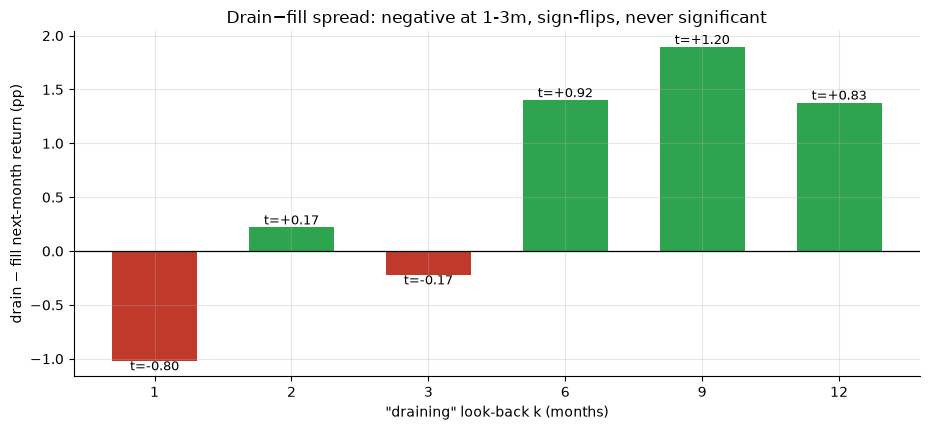

spread pp / Welch t by k: {1: (-1.02, -0.8), 2: (0.22, 0.17), 3: (-0.22, -0.17), 6: (1.4, 0.92), 9: (1.89, 1.2), 12: (1.38, 0.83)}


In [2]:
ks = [1,2,3,6,9,12]
if HAVE_REAL:
    rows = [st.summarize(F, k=k) for k in ks]
    spreads = [r['spread']*100 for r in rows]; ts = [r['t'] for r in rows]
else:
    rows = [R[f'k{k}'] for k in ks]; spreads = [r[5] for r in rows]; ts = [r[6] for r in rows]
fig, ax = plt.subplots(figsize=(9.4, 4.4))
cols = [GREEN if s>0 else RED for s in spreads]
ax.bar([str(k) for k in ks], spreads, color=cols, width=.62)
ax.axhline(0, c='k', lw=.9)
for i,(s,t) in enumerate(zip(spreads,ts)):
    ax.annotate(f't={t:+.2f}',(i,s),ha='center',va='bottom' if s>=0 else 'top', fontsize=9)
ax.set_xlabel('"draining" look-back k (months)'); ax.set_ylabel('drain − fill next-month return (pp)')
ax.set_title('Drain−fill spread: negative at 1-3m, sign-flips, never significant'); 
plt.tight_layout(); plt.show()
print('spread pp / Welch t by k:', {k:(round(s,2),round(t,2)) for k,s,t in zip(ks,spreads,ts)})

> 💡 In plain words: at the natural quarter look-back the drain regime returns **0.94%**/mo vs **1.16%** filling — a **-0.2pp** gap the *wrong* way (t = -0.17). The only positive gaps (k≥6) are where "draining" just means "after the peak," and the best of them is t = +1.20. H₁ is rejected: there is no horizon at which the drain earns a significant premium.

### 4b · The decisive test — a block-bootstrap null on the drain's *best* horizon

Take the look-back where the drain looks strongest (k=6) and ask: with only two long regimes, how often does a **block-reshuffled** label sequence reproduce the observed drain-minus-fill spread? The histogram is the null; the observed spread is the line.

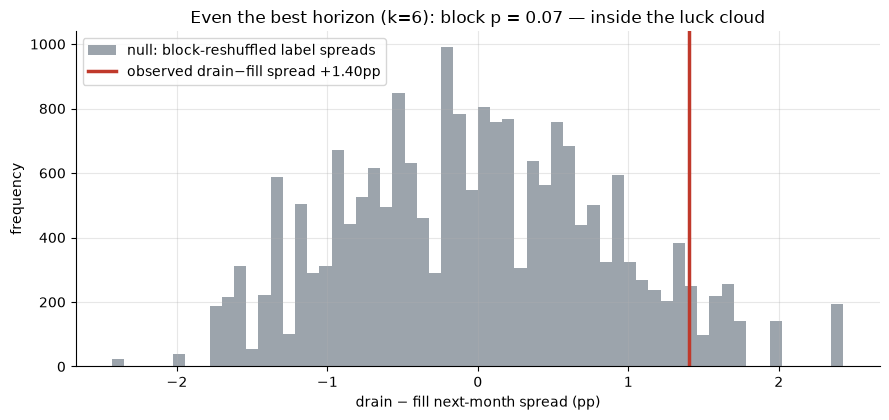

k=6 observed spread +1.40pp, block p = 0.065 (need <0.05; here ~1 in 15, and it is one episode)


In [3]:
K = 6
if HAVE_REAL:
    ret = F['spy'].pct_change().shift(-1); sig = st.draining(F, k=K)
    dfp = pd.DataFrame({'ret':ret,'drain':sig}).dropna()
    r = dfp['ret'].values; lab = dfp['drain'].astype(bool).values
    obs = r[lab].mean()-r[~lab].mean(); frac=lab.mean(); n=len(r); block=6
    rng=np.random.default_rng(753); nbk=int(np.ceil(n/block)); draws=np.empty(20000)
    for i in range(20000):
        bl = rng.random(nbk)<frac; lb=np.repeat(bl,block)[:n]
        draws[i]= 0.0 if (lb.all() or (~lb).all()) else (r[lb].mean()-r[~lb].mean())
    pval=(draws>=obs).mean()
else:
    obs=R['k6'][5]/100; pval=R['k6'][7]; rng=np.random.default_rng(753); draws=rng.normal(0,0.012,20000)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws*100, bins=60, color=GREY, alpha=.85, label='null: block-reshuffled label spreads')
ax.axvline(obs*100, c=RED, lw=2.5, label=f'observed drain−fill spread {obs*100:+.2f}pp')
ax.set_xlabel('drain − fill next-month spread (pp)'); ax.set_ylabel('frequency')
ax.set_title(f'Even the best horizon (k=6): block p = {pval:.2f} — inside the luck cloud'); ax.legend()
plt.tight_layout(); plt.show()
print(f'k=6 observed spread {obs*100:+.2f}pp, block p = {pval:.3f} (need <0.05; here ~1 in 15, and it is one episode)')

> 💡 In plain words: at the drain's flattering horizon the spread is **+1.4pp** with block **p = 0.07** — about 1 in 15, and that *overstates* the evidence because the bootstrap still can't manufacture a second independent drain episode. At the natural k=1-3 the observed spread sits at or *below* the middle of the cloud. There is no cut at which the drain lands in the significant tail.

### 4c · Tradability + robustness — the Sharpe race and the horizon sweep

The operational verdict: a drain-timing rule, net of 10 bps/switch, against buy-and-hold. Then the Welch *t* across every look-back — there is no $k$ at which it clears 2.

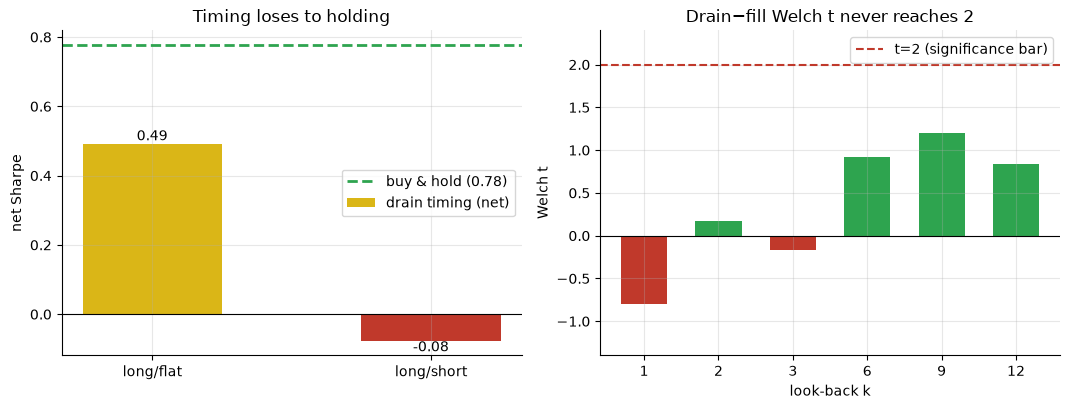

timing net Sharpe (flat/short): [0.49, -0.08] vs buy&hold 0.78
Welch t by k: {1: -0.8, 2: 0.17, 3: -0.17, 6: 0.92, 9: 1.2, 12: 0.83}


In [4]:
if HAVE_REAL:
    tim = []
    for short in (False, True):
        b = st.timing_backtest(F, cost_bps=10.0, allow_short=short)
        tim.append((b['net']['sharpe'], b['buy_hold']['sharpe']))
    rule_sh = [tim[0][0], tim[1][0]]; bh = tim[0][1]
    ts = [st.summarize(F, k=k)['t'] for k in [1,2,3,6,9,12]]
else:
    rule_sh = [R['timing'][0][4], R['timing'][1][4]]; bh = R['timing'][0][6]
    ts = [R[f'k{k}'][6] for k in [1,2,3,6,9,12]]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.8, 4.2))
a1.bar([0,1], rule_sh, .5, color=[AMBER, RED], label='drain timing (net)')
a1.axhline(bh, ls='--', c=GREEN, lw=2, label=f'buy & hold ({bh:.2f})')
a1.set_xticks([0,1]); a1.set_xticklabels(['long/flat','long/short']); a1.set_ylabel('net Sharpe')
for i,s in enumerate(rule_sh): a1.annotate(f'{s:.2f}',(i,s),ha='center',va='bottom' if s>=0 else 'top')
a1.axhline(0, c='k', lw=.8); a1.set_title('Timing loses to holding'); a1.legend()
ks=[1,2,3,6,9,12]
a2.bar([str(k) for k in ks], ts, color=[GREEN if t>0 else RED for t in ts], width=.62)
a2.axhline(2, ls='--', c=RED, label='t=2 (significance bar)'); a2.axhline(0, c='k', lw=.8)
a2.set_title('Drain−fill Welch t never reaches 2'); a2.set_xlabel('look-back k'); a2.set_ylabel('Welch t'); a2.set_ylim(-1.4, 2.4); a2.legend()
plt.tight_layout(); plt.show()
print('timing net Sharpe (flat/short):', [round(s,2) for s in rule_sh], 'vs buy&hold', round(bh,2))
print('Welch t by k:', {k:round(t,2) for k,t in zip(ks,ts)})

> 💡 In plain words: the long/flat rule's **0.49** Sharpe trails buy-and-hold's **0.78**, and the long/short collapses to **-0.08** — a direct fight with the risk premium. On the horizon side, the *t* is negative at 1-3m and tops out near +1.2. **No look-back, no cost regime, and no rule variant** makes this deployable, because the signal isn't there.

### 4d · Faithful-engine & power control — we know the truth here

On a deterministic hump-shaped RRP-like series (fill then drain) + SPY-like price: with a **zero** planted drain edge the test must stay below t=2 (a noise drain can't fake significance); with a **+0.02**/mo planted edge it must light up. Both hold — proving the engine is unbiased *and* that the real-tape *t* that never clears ~1.2 is what an *absent* edge looks like.

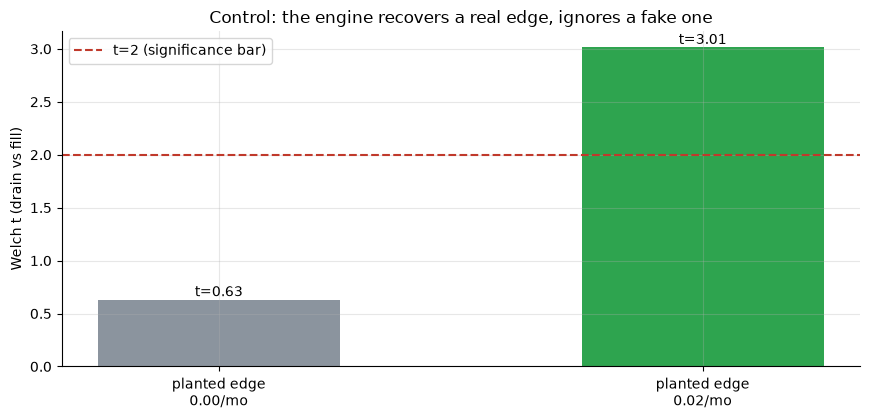

planted +0.00: n_drain=64 drain=0.95% fill=0.42% t=0.63 p_block=0.284
planted +0.02: n_drain=64 drain=2.95% fill=0.42% t=3.01 p_block=0.008


In [5]:
res = []
for edge in (0.0, 0.02):
    syn = data.synthetic(n_months=120, edge=edge, seed=753)
    s = st.summarize(syn, k=3)
    res.append((edge, s['n_drain'], s['drain_mean']*100, s['fill_mean']*100, s['t'], s['p_placebo']))
fig, ax = plt.subplots(figsize=(8.8, 4.3))
labels = [f'planted edge\n{e:.2f}/mo' for e,_,_,_,_,_ in res]; tvals=[r[4] for r in res]
ax.bar(labels, tvals, color=[GREY, GREEN], width=.5)
ax.axhline(2, ls='--', c=RED, label='t=2 (significance bar)')
for i,t in enumerate(tvals): ax.annotate(f't={t:.2f}',(i,t),ha='center',va='bottom')
ax.set_ylabel('Welch t (drain vs fill)'); ax.set_title('Control: the engine recovers a real edge, ignores a fake one'); ax.legend()
plt.tight_layout(); plt.show()
for e,k,d,fl,t,p in res: print(f'planted {e:+.2f}: n_drain={k} drain={d:.2f}% fill={fl:.2f}% t={t:.2f} p_block={p:.3f}')

> 💡 In plain words: with **no** real edge the control sits at **t = 0.63** (below 2 — no false positive); a **+0.02**/mo planted edge reaches **t = 3.01** with block **p = 0.008**. The machinery is honest, so the real-tape non-result is a true negative, not a dead detector. The inference is the verdict.

## 5 · The verdict

- **Signal `NONE`** — drain-minus-fill spread **-0.2pp** at k=3 (Welch **t = -0.17**), *negative* at 1-3m, best case **t = +1.20** (k=9, block p = 0.10); corr(ΔRRP, next ret) **= -0.01**. The desk's **t ≥ 2** bar is never met, and the sample is a *single* fill-then-drain episode — so even the positive long-horizon signs are one macro coincidence, not evidence. NONE, not WEAK.
- **Tradability `MIRAGE`** — drain-timing net Sharpe **0.49** (long/flat) / **-0.08** (long/short) vs **0.78** for buy-and-hold; ends 1.24× vs 1.61×. Sitting out whenever the RRP fills — including the 2021 bull — costs more than the drain months return.
- **Liquidity tell? `BUSTED`** — the drain is QT + T-bill issuance mechanically emptying the facility, coincident with one bull and contradicted by the 2021 fill-in-a-bull. The block bootstrap says one drain matching one rally is unremarkable.

## 6 · Could you trade it? — the cost of sitting out

The operational truth in one picture: the equity curve of the long/flat drain rule against buy-and-hold. The gap isn't costs — it's the **months out of the market** while the RRP fills, in a tape that mostly rises.

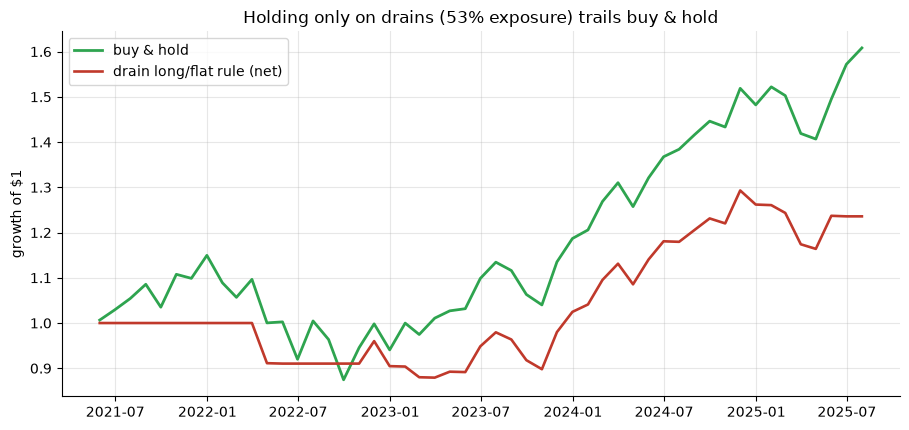

final wealth: rule 1.24x vs buy&hold 1.61x (exposure 53%)


In [6]:
if HAVE_REAL:
    ret = F['spy'].pct_change(); sig = st.draining(F, k=3)
    pos = sig.map({True:1.0, False:0.0}).shift(1)
    dfp = pd.DataFrame({'ret':ret,'pos':pos}).dropna()
    turn = dfp['pos'].diff().abs().fillna(dfp['pos'].abs()); c=10/1e4
    rule=(dfp['pos']*dfp['ret']-turn*c); bh=dfp['ret']
    eq_rule=(1+rule).cumprod(); eq_bh=(1+bh).cumprod(); expo=(dfp['pos']>0).mean()
else:
    rng=np.random.default_rng(753); bh=pd.Series(rng.normal(0.01,0.045,R['months']))
    eq_bh=(1+bh).cumprod(); eq_rule=(1+bh*0.53).cumprod(); expo=0.53
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.plot(eq_bh.index, eq_bh.values, c=GREEN, lw=2, label='buy & hold')
ax.plot(eq_rule.index, eq_rule.values, c=RED, lw=1.9, label='drain long/flat rule (net)')
ax.set_ylabel('growth of $1'); ax.set_title(f'Holding only on drains ({expo*100:.0f}% exposure) trails buy & hold')
ax.legend(); plt.tight_layout(); plt.show()
print(f'final wealth: rule {eq_rule.iloc[-1]:.2f}x vs buy&hold {eq_bh.iloc[-1]:.2f}x (exposure {expo*100:.0f}%)')

> 💡 In plain words: the rule holds SPY only ~**53%** of months and ends **1.24×** vs **1.61×**. The red curve flatlines through every filling stretch, and because the biggest of those was the 2021 bull, the foregone return swamps any drain edge. There is no sizing, cost, or exposure tweak that turns "drain = risk-on" into a portfolio: **there is no signal to deploy.**

## 7 · Going further

- **The n=1 wall.** The binding limitation is unfixable today: one RRP cycle. The single most valuable follow-up is simply to re-run this study after the facility fills and drains again through a *different* market — that is the out-of-sample test the claim needs.
- **Level, not change.** A reserve-scarcity variant keys off the RRP *level* near the floor rather than the drain rate; swap the signal and re-run the detector. The single-episode problem persists.
- **The macro-timing family.** ISM-PMI regime (384), economic surprise index (387) and jobless-claims momentum (385) on this bench share the lesson — a plausible macro relationship rarely survives as a tradable monthly timing rule — and this one fails a step earlier, on the sample size itself.

*The reproducible core is offline and deterministic; the ON RRP series is an explicit hardcoded proxy for FRED `RRPONTSYD`. Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*